## Exploratory Data Analysis of "New Italian Glacier Inventory"

The datasets can be found at:

- Trentino: [https://sites.unimi.it/glaciol/wp-content/uploads/2019/02/6-trentino.pdf](https://sites.unimi.it/glaciol/wp-content/uploads/2019/02/6-trentino.pdf)

- South Tyrol: [https://sites.unimi.it/glaciol/wp-content/uploads/2019/02/7-alto-adige.pdf](https://sites.unimi.it/glaciol/wp-content/uploads/2019/02/7-alto-adige.pdf)

- Piedmont: [http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/3-piemonte.pdf](http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/3-piemonte.pdf)

- Aosta Valley: [http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/4-valle-daosta.pdf](http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/4-valle-daosta.pdf)

- Lombardy: [http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/5-Lombardia.pdf](http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/5-Lombardia.pdf)

- Veneto: [http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/8-veneto.pdf](http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/8-veneto.pdf)

- Friuli Venezia Giulia: [http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/9-friuli-veneziagiulia.pdf](http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/9-friuli-veneziagiulia.pdf)

- Abruzzo: [http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/10-Abruzzo.pdf](http://sites.unimi.it/glaciol/wp-content/uploads/2019/02/10-Abruzzo.pdf)

The New Italian Glacier Inventory is a project realized in 2016 at the “Ardito Desio” Earth Science Department of the University of Milan (henceforth UNIMI) by the Glaciology staff. 

It aims to answer the following crucial questions: How many are the actual glaciers of Italy? What is the present glacier coverage in Italy? How hard and how fast has the climate change impacted the cold and frozen water resources of the Italian Alps?

This project was accredited and recognized by the World Glacier Monitoring Service (henceforth WGMS), which is the organization that developed and presently manages the World Glacier Inventory. They recognize the significant contribution of the UniMi project for establishing regional to global
coverage and document glacier changes in space and time.


In [10]:
region = "Trentino"  # Change to "Alto Adige" for Alto Adige dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = None
if region == "Trentino":
    df = pd.read_csv('../data/raw/trentino-unimi.csv', header=0, sep=';')
else:
    df = pd.read_csv('../data/raw/altoadige-unimi.csv', header=0, sep=';')
print(f"Shape of {region} dataset: {df.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Glacier Name        116 non-null    str  
 1   ID Code             116 non-null    str  
 2   WGI Code            116 non-null    str  
 3   Mountain Sector     116 non-null    str  
 4   Mountain Catchment  116 non-null    str  
 5   Glacier Type        116 non-null    str  
 6   Area (km2)          116 non-null    str  
 7   Area CGI (km2)      116 non-null    str  
 8   Area WGI (km2)      116 non-null    str  
 9   Aspect              116 non-null    str  
 10  Year                116 non-null    int64
 11  Notes               98 non-null     str  
dtypes: int64(1), str(11)
memory usage: 24.8 KB
Shape of Trentino dataset: None


### Fields Description


The data are characterized as follows:

`Glacier Name`: name of the glacier according to CGI inventory (1959-1962)

`ID Code`: code reported in the CGI inventory. In the case of glaciers newly formed due to fragmentation phenomena and without previous inclusion in the CGI data base, the ID code was based on the CGI inventory code for the main fragmented glacier, with the ending addition of a dot and an ordinal number (e.g.: .1, .2, etc..).

`WGI code`: WGI official code. Empty if the glacier was not identified in the past (e.g., newly formation due to fragmentation phenomena).

`Mountain Sector`: nesting mountain group by applying the SOIUSA (International Standardized Mountain Subdivision of the Alps) .

`Mountain catchment`:  main mountain catchment (a drainage basin in a mountainous area, where rain, snowmelt and groundwater flow to feed streams, rivers and lakes)

`Glacier Type`: three main types based on previous classifications:

- *valley glacier*: an ice body featuring an accumulation basin from which originates an ablation tongue flowing downward between the walls of the valley, which needs to be clearly shaped and evident from a geomorphological point of view.
    
- *mountain glacier*: a glacier, even of considerable size, which does not develop an ablation tongue and which is located on mountain slopes.

- glacieret: restricted ice body of unclear shape and morphology, with slow or absent ice flow. This type was attributed this to all the ice bodies featuring a surface area less than $0.5 km^2$

(* ablation tongue: the elongated section of a glacier that extends into warmer elevations)

`Area (km2)`: reported area in $km^2$ according to most recent data sources

`Area CGI (km2)`: area value (in $km^2$) reported in the CGI inventory (1959-1962)

`Area WGI (km2)`:  area value (in $km^2$) reported in the WGI. These values are referred to data sources dating between the end of the 1970s and the beginning of the 1980

`Aspect`: aspect of the glacier considering 45° aspect bins, thus giving 8 main
classes: N, NE, E, SE, S, SO, O, NO

`Year`: year of the acquisition of the data from the main source

`Notes`: used to list information on glacier name, occurrence of fragmentation, glacier fusion, glacier extinction, occurrence of supraglacial debris, detachment of a part of the glacier body, etc…

In [12]:
df['Area (km2)'] = pd.to_numeric(df['Area (km2)'], errors='coerce')
df['Area CGI (km2)'] = pd.to_numeric(df['Area CGI (km2)'], errors='coerce')
df['Area WGI (km2)'] = pd.to_numeric(df['Area WGI (km2)'], errors='coerce')

In [13]:
df['Newly Formed'] = df['ID Code'].str.contains('\.')

In [14]:
df.head()

,Glacier Name,ID Code,WGI Code,Mountain Sector,Mountain Catchment,Glacier Type,Area (km2),Area CGI (km2),Area WGI (km2),Aspect,Year,Notes,Newly Formed
0,Corno dei Tre Signori N-E,685,IT4L00102501,Ortles-Cevedale (Retiche Meridionali),ADIGE - Noce,Glacieret,0.06,0.10,0.15,NE,2011,Interamente coperto da detrito.,False
1,Villacorna,686,IT4L00102502,Ortles-Cevedale (Retiche Meridionali),ADIGE - Noce,Mountain,0.10,0.28,0.32,SE,2011,Totalmente coperto da detrito.,False
2,Valpiana,687,IT4L00102503,Ortles-Cevedale (Retiche Meridionali),ADIGE - Noce,Mountain,0.16,0.69,0.56,SE,2011,Include il M. Giumella (687.1) nei catasti CGI...,False
3,Monte Giumella,687.1,N.D.,Ortles-Cevedale (Retiche Meridionali),ADIGE - Noce,Mountain,0.09,NaN,NaN,S,2011,Non elencato singolarmente nei catasti CGI/WGI...,True
4,Orsi,688,IT4L00102505,Ortles-Cevedale (Retiche Meridionali),ADIGE - Noce,Mountain,0.64,1.12,1.51,SE,2011,NaN,False


In [15]:
df.aggregate({
    'Area (km2)': ['sum', 'mean', 'min', 'max'],
    'Area CGI (km2)': ['sum', 'mean', 'min', 'max'],
    'Area WGI (km2)': ['sum', 'mean', 'min', 'max']
})

,Area (km2),Area CGI (km2),Area WGI (km2)
sum,29.040000,33.850000,50.500000
mean,0.254737,0.497794,0.765152
min,0.010000,0.020000,0.070000
max,5.860000,5.050000,7.840000


In [16]:
df.groupby('Mountain Sector').aggregate({
    'Area (km2)': ['sum', 'mean', 'min', 'max'],
    'Area CGI (km2)': ['sum', 'mean', 'min', 'max'],
    'Area WGI (km2)': ['sum', 'mean', 'min', 'max']
})

Area (km2)                        \
                                             sum      mean   min   max   
Mountain Sector                                                          
Adamello-Presanella                        18.41  0.317414  0.01  5.86   
Dolomiti di Brenta                          0.86  0.043000  0.01  0.19   
Marmolada (Dolomiti)                        0.26  0.043333  0.01  0.10   
Ortles-Cevedale (Retiche Meridionali)       9.22  0.384167  0.01  3.52   
Pale di San Martino                         0.29  0.048333  0.01  0.16   

                                      Area CGI (km2)                        \
                                                 sum      mean   min   max   
Mountain Sector                                                              
Adamello-Presanella                            15.05  0.418056  0.02  3.92   
Dolomiti di Brenta                              2.80  0.254545  0.10  0.51   
Marmolada (Dolomiti)                            0.61  0.203333  0.02  0.47   
Ortles-Cevedale (Retiche Meridionali)          14.60  0.912500  0.06  5.05   
Pale di San Martino                             0.79  0.395000  0.14  0.65   

                                      Area WGI (km2)                        
                                                 sum      mean   min   max  
Mountain Sector                                                             
Adamello-Presanella                            28.81  0.847353  0.07  7.84  
Dolomiti di Brenta                              2.09  0.209000  0.08  0.42  
Marmolada (Dolomiti)                            0.65  0.216667  0.12  0.38  
Ortles-Cevedale (Retiche Meridionali)          18.17  1.135625  0.15  4.75  
Pale di San Martino                             0.78  0.260000  0.07  0.43

In [17]:
df.groupby('Glacier Type').aggregate({
    'Area (km2)': ['sum', 'mean', 'min', 'max'],
    'Area CGI (km2)': ['sum', 'mean', 'min', 'max'],
    'Area WGI (km2)': ['sum', 'mean', 'min', 'max']
})

Area (km2)                       Area CGI (km2)            \
                          sum      mean   min   max            sum      mean   
Glacier Type                                                                   
Altopiano / Lingue       0.00       NaN   NaN   NaN           0.00       NaN   
Glacieret                1.45  0.026364  0.01  0.09           2.78  0.102963   
Mountain                21.47  0.376667  0.02  5.86          23.45  0.601282   
Valley                   6.12  3.060000  2.60  3.52           7.62  3.810000   

                               Area WGI (km2)                        
                     min   max            sum      mean   min   max  
Glacier Type                                                         
Altopiano / Lingue   NaN   NaN           0.00       NaN   NaN   NaN  
Glacieret           0.02  0.51           4.84  0.193600  0.07  0.42  
Mountain            0.04  5.05          36.99  0.948462  0.11  7.84  
Valley              3.70  3.92           8.67  4.335000  3.92  4.75

### Plots

In [18]:
FIVE_COL_AREA = ["#636B7F", '#89A3E0', '#C1DFF0', '#E0E5E8', '#A9B0B8']
FIVE_COL_COUNTS = ["#7F6C63", "#AC5239", "#D9A066", "#F2CBA0", "#E0BFA9"]

In [29]:
# # plot number of glaciers for Mountain Sector
# plt.figure(figsize=(10, 3.5))

# new_counts = df.groupby('Mountain Sector')['Newly Formed'].sum()

# sector_counts = df['Mountain Sector'].value_counts()

# plt.barh(sector_counts.index, sector_counts.values, color = FIVE_COL_COUNTS[1], label='Total Glaciers')
# plt.barh(new_counts.index, new_counts.values, color = FIVE_COL_COUNTS[2], label='Newly formed glaciers')
# plt.xlabel('Number of Glaciers')
# plt.title('Number of Glaciers by Mountain Sector in ' + region)
# plt.legend()


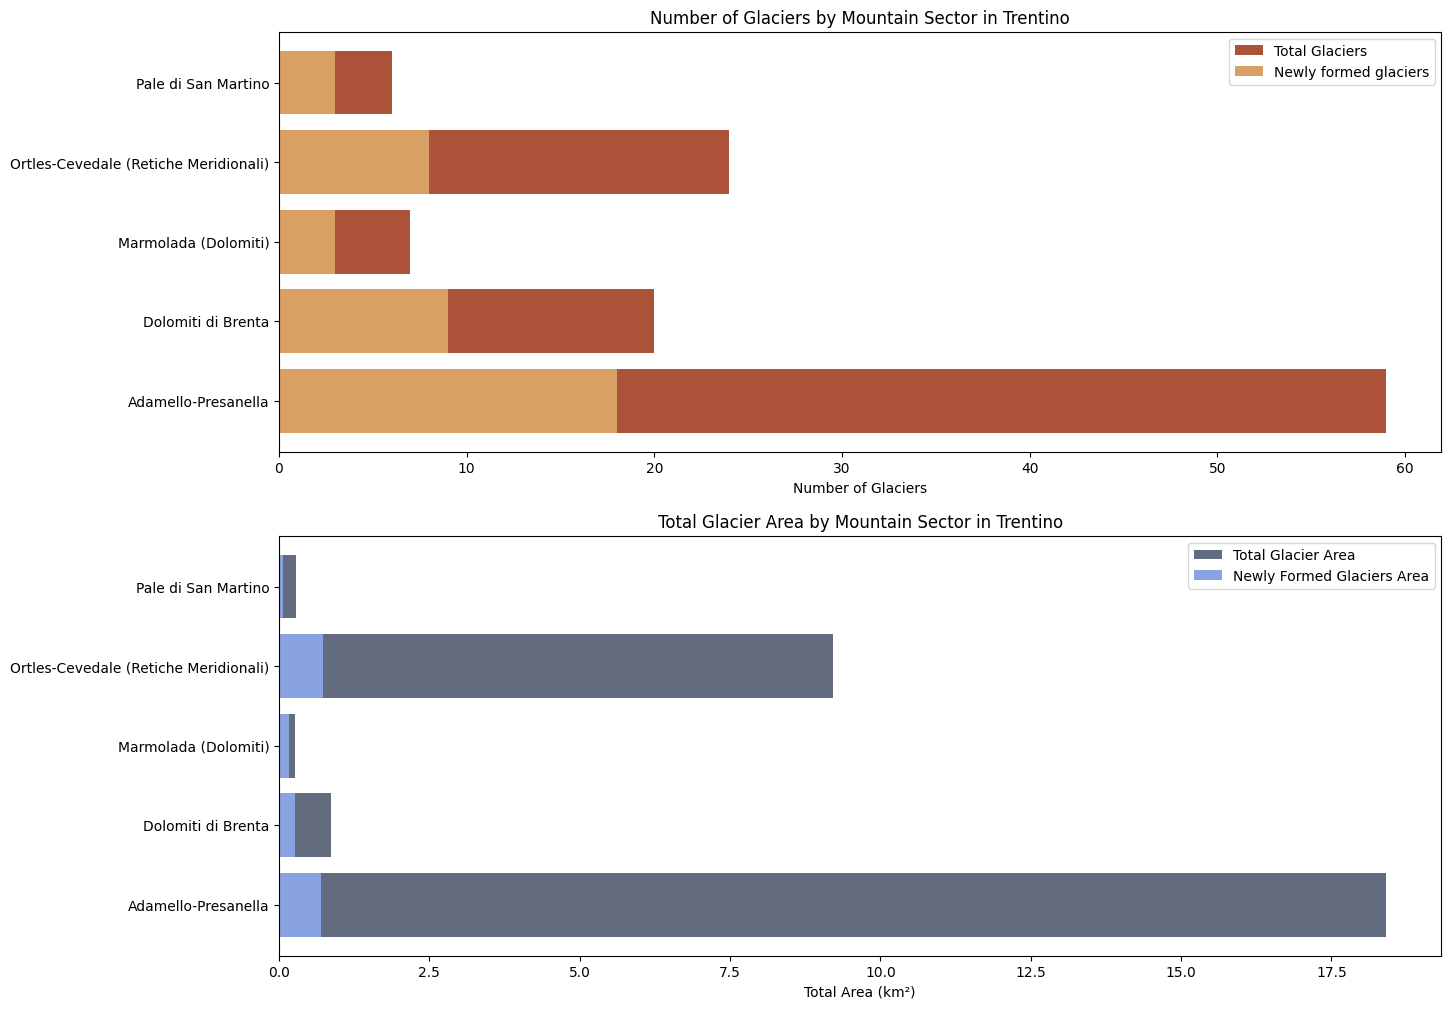

In [47]:
#use two subplots
fig, axs = plt.subplots(2, 1, figsize=(15, 12))
new_counts = df.groupby('Mountain Sector')['Newly Formed'].sum()

sector_counts = df['Mountain Sector'].value_counts().sort_index()

axs[0].barh(sector_counts.index, sector_counts.values, color = FIVE_COL_COUNTS[1], label='Total Glaciers')
axs[0].barh(new_counts.index, new_counts.values, color = FIVE_COL_COUNTS[2], label='Newly formed glaciers')
axs[0].set_xlabel('Number of Glaciers')
axs[0].set_title('Number of Glaciers by Mountain Sector in ' + region)
axs[0].legend()

# plot area of glaciers for Mountain Sector
# plt.figure(figsize=(10, 3.5))
new_area = df[df['Newly Formed']].groupby('Mountain Sector')['Area (km2)'].sum()
sector_area = df.groupby('Mountain Sector')['Area (km2)'].sum()
axs[1].barh(sector_area.index, sector_area.values, color = FIVE_COL_AREA[0], label='Total Glacier Area')
axs[1].barh(new_area.index, new_area.values, color = FIVE_COL_AREA[1], label='Newly Formed Glaciers Area')
axs[1].set_xlabel('Total Area (km²)')
axs[1].set_title('Total Glacier Area by Mountain Sector in ' + region)
axs[1].legend()


In [30]:
# # plot area of glaciers for Mountain Sector
# plt.figure(figsize=(10, 3.5))
# new_area = df[df['Newly Formed']].groupby('Mountain Sector')['Area (km2)'].sum()
# sector_area = df.groupby('Mountain Sector')['Area (km2)'].sum()
# plt.barh(sector_area.index, sector_area.values, color = FIVE_COL_AREA[0], label='Total Glacier Area')
# plt.barh(new_area.index, new_area.values, color = FIVE_COL_AREA[1], label='Newly formed glacier area')
# plt.xlabel('Total Area (km²)')
# plt.title('Total Glacier Area by Mountain Sector in ' + region)
# plt.legend()

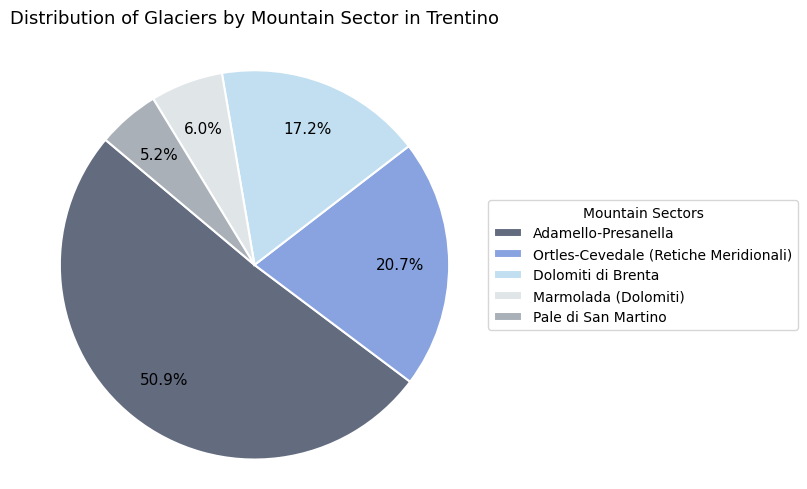

In [259]:
plt.figure(figsize=(8, 5))

value_counts = df['Mountain Sector'].value_counts().sort_values(ascending=False)

wedges, texts, autotexts = plt.pie(
    value_counts.values, 
    autopct='%1.1f%%', 
    colors=FIVE_COL_AREA, 
    pctdistance=0.75,         # Moves numbers slightly inward
    startangle=140, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.setp(autotexts, size=11)

plt.legend(wedges, value_counts.index,
          title="Mountain Sectors",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Distribution of Glaciers by Mountain Sector in ' + region, 
          pad=20, fontsize=13)
plt.axis('equal')
plt.tight_layout()
plt.show()

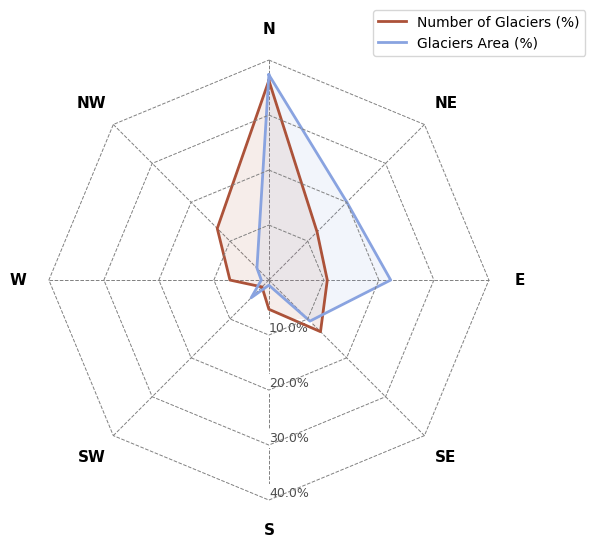

In [251]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick  # Imported for percentage formatting
from matplotlib.path import Path
from matplotlib.spines import Spine

# 1. Clean and reindex your data
aspect_num_cleaned = df[(df['Aspect'] != 'N.D.') & (df['Aspect'] != 'SW / W')]['Aspect'].value_counts()
aspect_num_cleaned = aspect_num_cleaned.reindex(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fill_value=0)

aspect_area_cleaned = df[(df['Aspect'] != 'N.D.') & (df['Aspect'] != 'SW / W')].groupby('Aspect')['Area (km2)'].sum()
aspect_area_cleaned = aspect_area_cleaned.reindex(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'], fill_value=0)

# Convert values to percentages relative to the cleaned totals ---
pct_num = (aspect_num_cleaned / aspect_num_cleaned.sum()) * 100
pct_area = (aspect_area_cleaned / aspect_area_cleaned.sum()) * 100

# 2. Compute the angles in radians for 8 directions (0 to 2*pi)
# (Since both share the same 8 categories, angles_num and angles_area are identical)
angles_num = np.linspace(0, 2 * np.pi, len(pct_num), endpoint=False)
angles_area = np.linspace(0, 2 * np.pi, len(pct_area), endpoint=False)

# Close the loop by appending the first value to the end
angles_num = np.concatenate((angles_num, [angles_num[0]]))
values_num = np.concatenate((pct_num.values, [pct_num.values[0]]))
labels = list(pct_num.index)

angles_area = np.concatenate((angles_area, [angles_area[0]]))
values_area = np.concatenate((pct_area.values, [pct_area.values[0]]))

# 3. Setup the polar plot
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

# 4. Plot the data (Now both use the same % scale!)
ax.plot(angles_num, values_num, linewidth=2, linestyle='solid', color=FIVE_COL_COUNTS[1], label='Number of Glaciers (%)')
ax.fill(angles_num, values_num, alpha=0.1, color=FIVE_COL_COUNTS[1])

ax.plot(angles_area, values_area, linewidth=2, linestyle='solid', color=FIVE_COL_AREA[1], label='Glaciers Area (%)')
ax.fill(angles_area, values_area, alpha=0.1, color=FIVE_COL_AREA[1])

# 5. Fix the labels: Set ticks where the angles are, and label them with compass directions
ax.set_xticks(angles_num[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

# Move the text labels to 22.5 degrees (between North and NE) so they sit in empty space
ax.set_rlabel_position(180) 

# Boost visibility of the percentage text with a clean background box
plt.setp(ax.get_yticklabels(), fontsize=9, alpha=0.7,
         bbox=dict(facecolor='white', edgecolor='none', alpha=1, pad=2))

# --- FIX: Turn the circle grid into an Octagon ---
ax.spines['polar'].set_visible(False) # Hide the default outer circle
ax.grid(False)                         # Hide the default circular grid rings

# Manually draw straight octagon grid lines at 25%, 50%, 75%, and 100%
grid_ticks = [10, 20, 30, 40]
ax.set_yticks(grid_ticks, )

for tick in grid_ticks:
    # Draw a straight-edged polygon ring for each grid interval
    ax.plot(angles_num, [tick]*len(angles_num), color='grey', linestyle='--', linewidth=0.7)

# Draw the straight spokes connecting the center to each compass label
for angle in angles_num[:-1]:
    ax.plot([angle, angle], [0, 40], color='grey', linestyle='--', linewidth=0.7, zorder=0)

plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

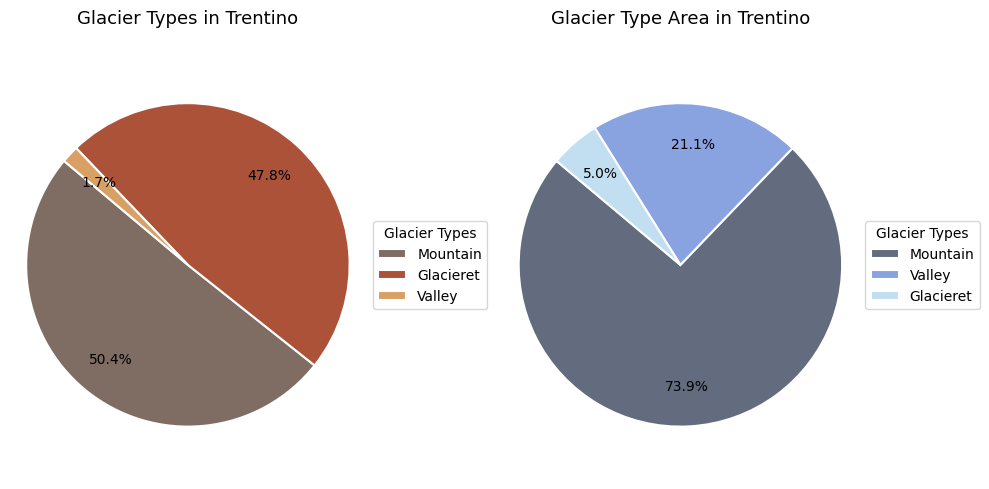

In [63]:
# plt.figure(figsize=(8, 5))
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

df.drop(df[df['Glacier Type'] == 'Altopiano / Lingue'].index, inplace=True)
value_counts = df['Glacier Type'].value_counts().sort_values(ascending=False)

wedges_counts, texts_counts, autotexts_counts = ax[0].pie(
    value_counts.values, 
    autopct='%1.1f%%', 
    colors=FIVE_COL_COUNTS, 
    pctdistance=0.75,         # Moves numbers slightly inward
    startangle=140, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax[0].legend(wedges_counts, value_counts.index,
              title="Glacier Types",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

ax[0].set_title('Glacier Types in ' + region, 
                 pad=20, fontsize=13)
ax[0].axis('equal')

value_area = df.groupby('Glacier Type')['Area (km2)'].sum().sort_values(ascending=False)
wedges_area, texts_area, autotexts_area = ax[1].pie(
    value_area.values, 
    autopct='%1.1f%%', 
    colors=FIVE_COL_AREA, 
    pctdistance=0.75,         # Moves numbers slightly inward
    startangle=140, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax[1].legend(wedges_area, value_area.index,
              title="Glacier Types",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))
ax[1].set_title('Glacier Type Area in ' + region, 
                 pad=20, fontsize=13)
ax[1].axis('equal')
plt.tight_layout()


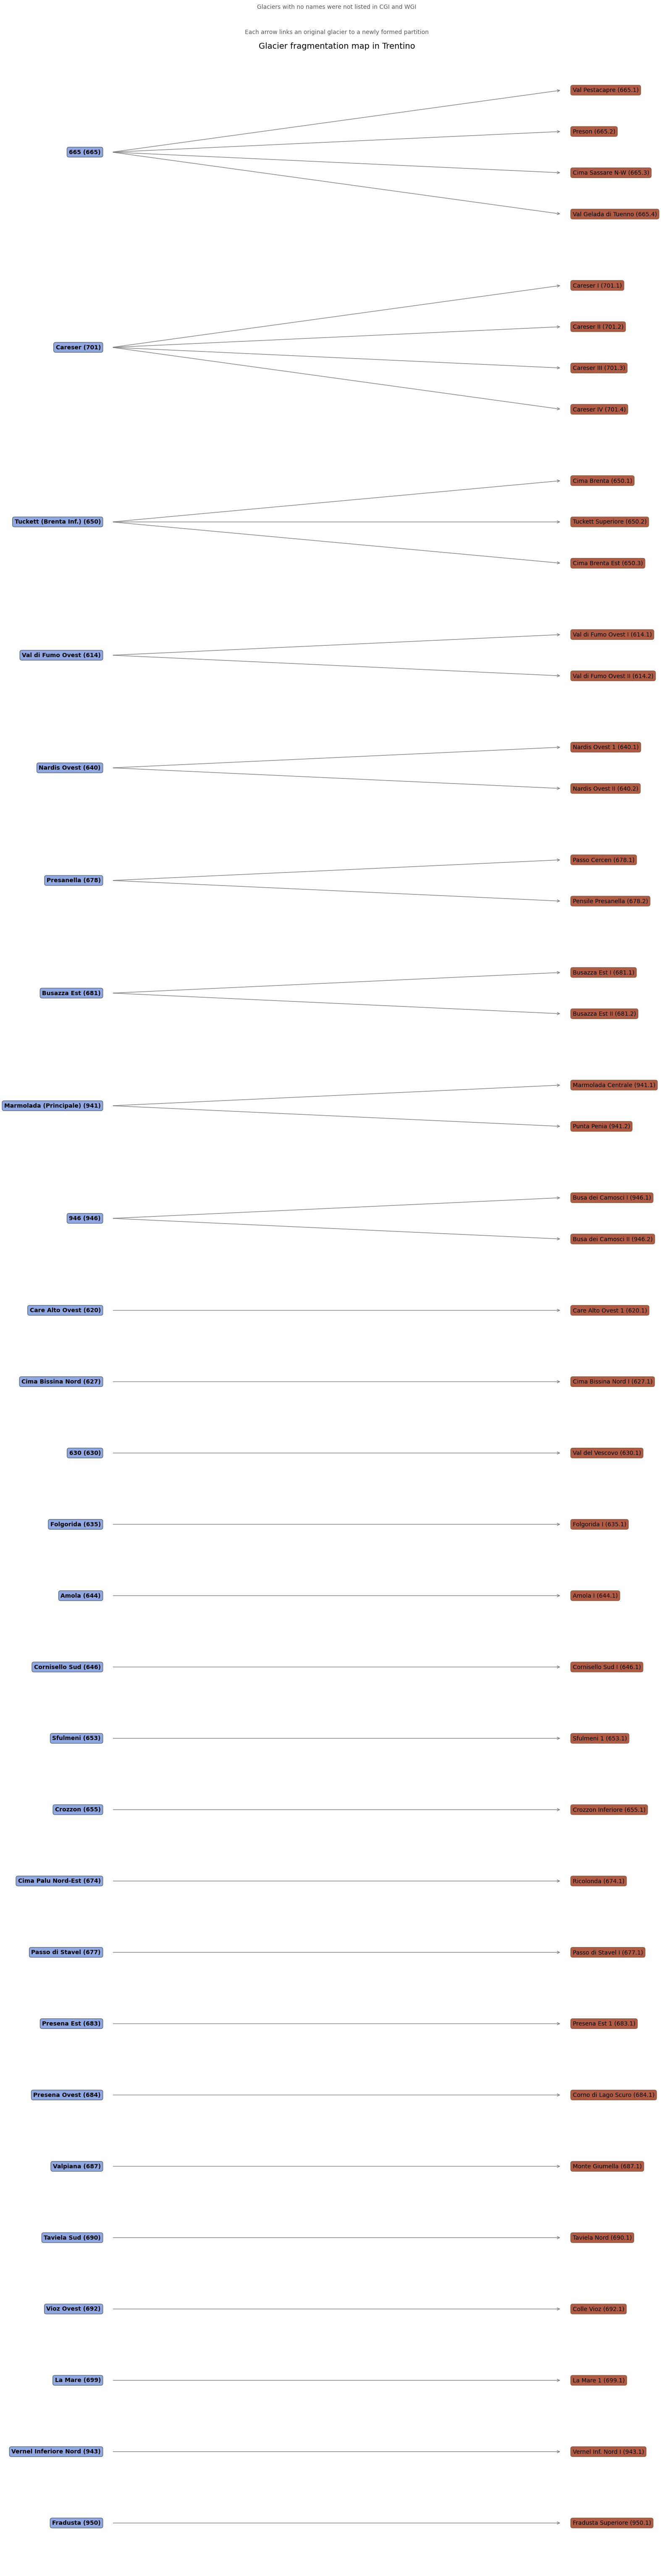

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fragmented = df[df['ID Code'].astype(str).str.contains(r'\.', na=False)].copy()
fragmented['ID Code'] = fragmented['ID Code'].astype(str)
fragmented['Parent Code'] = fragmented['ID Code'].str.split('.', n=1).str[0]
fragmented['Fragment Number'] = pd.to_numeric(
    fragmented['ID Code'].str.split('.', n=1).str[1],
    errors='coerce'
 )

parent_lookup = (
    df.assign(**{'ID Code': df['ID Code'].astype(str)})
      .drop_duplicates(subset='ID Code')
      .set_index('ID Code')['Glacier Name']
      .to_dict()
 )

fragmented['Parent Name'] = fragmented['Parent Code'].map(parent_lookup).fillna(fragmented['Parent Code'])
fragmented['Parent Label'] = fragmented['Parent Name'].astype(str) + ' (' + fragmented['Parent Code'] + ')'
fragmented['Child Label'] = fragmented['Glacier Name'].astype(str) + ' (' + fragmented['ID Code'] + ')'

groups = []
for parent_code, group in fragmented.groupby('Parent Code', sort=False):
    groups.append((parent_code, group.sort_values(['Fragment Number', 'ID Code'])))

groups.sort(key=lambda item: (-len(item[1]), item[0]))

fig_height = max(6, 0.9 * sum(len(group) + 1 for _, group in groups))
fig, ax = plt.subplots(figsize=(16, fig_height))

left_x, right_x = 0.08, 0.92
parent_box = dict(boxstyle='round,pad=0.35', facecolor=FIVE_COL_AREA[1], edgecolor='#506070', alpha=0.95)
child_box = dict(boxstyle='round,pad=0.35', facecolor=FIVE_COL_COUNTS[1], edgecolor='#805840', alpha=0.95)

y = 0.0
vertical_gap = 1.1
group_gap = 0.8

for parent_code, group in groups:
    child_ys = []
    for _, row in group.iterrows():
        child_y = -y
        child_ys.append(child_y)
        ax.text(
            right_x,
            child_y,
            row['Child Label'],
            ha='left',
            va='center',
            fontsize=10,
            bbox=child_box,
        )
        y += vertical_gap

    parent_label = f"{group.iloc[0]['Parent Name']} ({parent_code})"
    parent_y = sum(child_ys) / len(child_ys)
    ax.text(
        left_x,
        parent_y,
        parent_label,
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
        bbox=parent_box,
    )

    for child_y in child_ys:
        ax.annotate(
            '',
            xy=(right_x - 0.02, child_y),
            xytext=(left_x + 0.02, parent_y),
            arrowprops=dict(arrowstyle='->', color='0.45', lw=1.2, alpha=0.8),
        )

    y += group_gap

ax.set_title('Glacier fragmentation map in ' + region, fontsize=14, pad=20)
ax.text(
    0.5,
    1.01,
    'Each arrow links an original glacier to a newly formed partition',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=10,
    color='0.35',
 )
ax.text(
    0.5,
    1.02,
    'Glaciers with no names were not listed in CGI and WGI',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=10,
    color='0.35',
 )

ax.set_xlim(0, 1)
ax.set_ylim(-y + 0.6, 0.8)
ax.set_axis_off()
plt.tight_layout()
plt.show()